In [2]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 906.2 kB/s eta 0:00:44
    --------------------------------------- 0.5/40.2 MB 906.2 kB/s eta 0:00:44
    --------------------------------------- 0.8/40.2 MB 724.0 kB/s eta 0:00:55
    --------------------------------------- 0.8/40.2 MB 724.0 kB/s eta 0:00:55
   - -------------------------------------- 1.0/40.2 MB 667.2 kB/s eta 0:00:59
   - -------------------------------------- 1.0/40.2 MB 667.2 kB/s eta 0:00:59
   - -------------------------------------- 1.0/40.2 MB 667.2 kB/s eta 0:00:59
   - -------------------------------------- 1.0/40.2 MB 667.2 kB/s eta 0:00:59
   - -------------------------------------- 1.3/40.2 MB 540.4 kB/s eta 0:01:12
 


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pathlib import Path

In [10]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook into the target layer
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    # IMPORTANT: These methods MUST be inside the class with proper indentation
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_image, target_class=None):
        # Forward pass
        output = self.model(input_image)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        # Zero gradients, backward pass for target class
        self.model.zero_grad()
        target = output[0, target_class]
        target.backward()
        
        # Calculate weights
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the activations
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        # Generate heatmap
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = np.maximum(heatmap.cpu().numpy(), 0)
        heatmap /= np.max(heatmap)  # Normalize
        
        return heatmap, target_class

In [7]:
def setup_gradcam():
    # Load your best ResNet18 model
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.load_state_dict(torch.load("artifacts/models/resnet18_best.pth", map_location='cpu'))
    model.eval()
    # target layer (last convulationa layer in resnet18)
    target_layer=model.layer4[1].conv2

    return model,GradCAM(model,target_layer)

In [11]:
def visualize_gradcam(image_path, model, gradcam, class_names=['NORMAL', 'PNEUMONIA']):
    # Load and preprocess image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)
    
    # Generate Grad-CAM
    heatmap, predicted_class = gradcam.generate(input_tensor)
    
    # Resize heatmap to match image
    heatmap = cv2.resize(heatmap, (img.width, img.height))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Superimpose
    img_array = np.array(img)
    superimposed = cv2.addWeighted(img_array, 0.6, heatmap, 0.4, 0)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array)
    axes[0].set_title(f"Original X-ray\nTrue: {image_path.parent.name}")
    axes[0].axis('off')
    
    axes[1].imshow(heatmap)
    axes[1].set_title(f"Heatmap\nModel looking here")
    axes[1].axis('off')
    
    axes[2].imshow(superimposed)
    axes[2].set_title(f"Grad-CAM Overlay\nPredicted: {class_names[predicted_class]}")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return predicted_class


Visualizing Pneumonia Case:


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


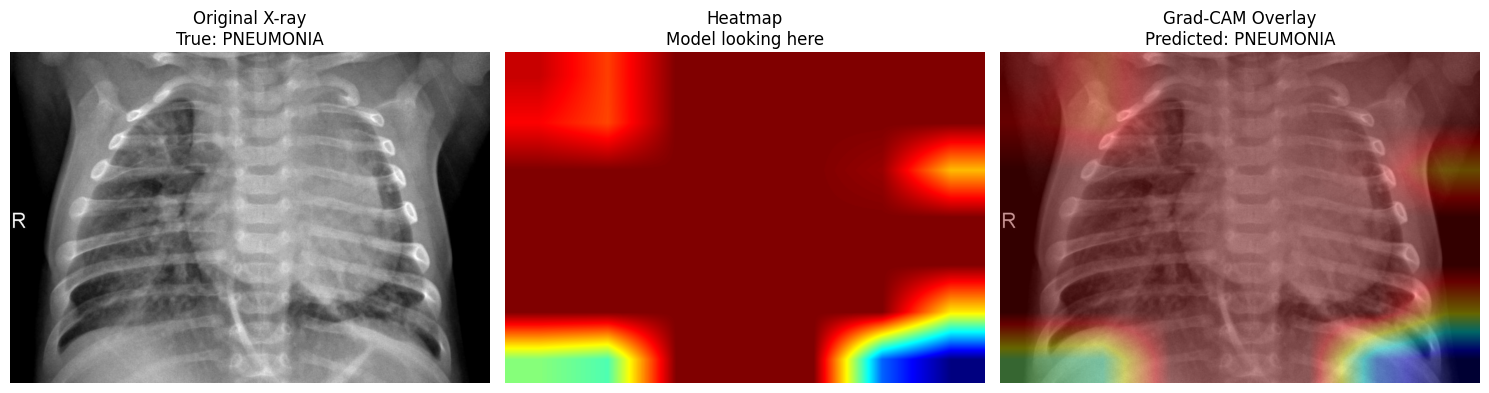


Visualizing Normal Case:


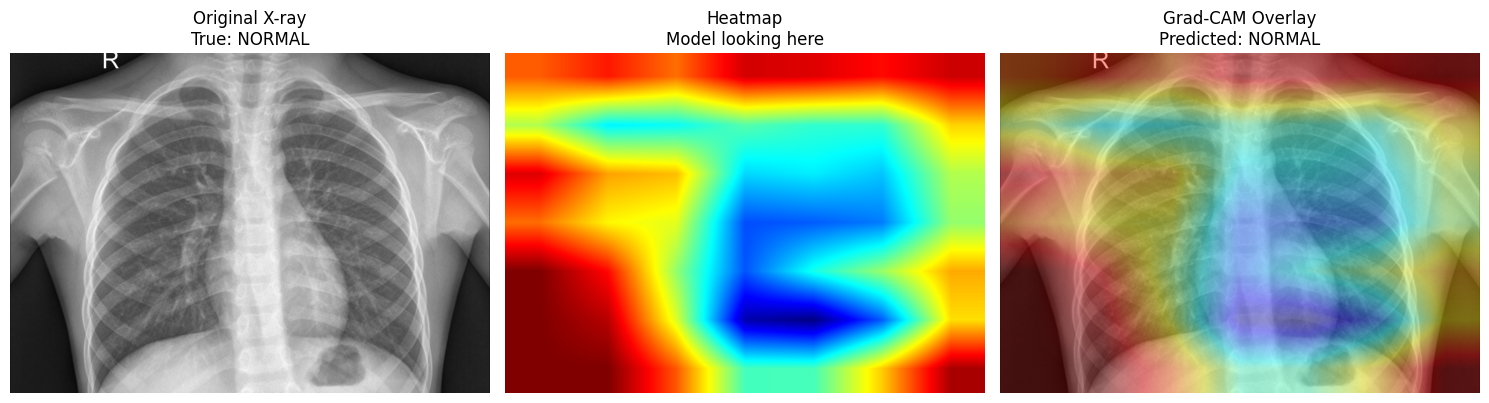

0

In [12]:
# Test on Sample Images
model, gradcam = setup_gradcam()

# Test on a pneumonia image
print("Visualizing Pneumonia Case:")
pneumonia_path = Path(r"C:\Users\HP\Desktop\pneumonia_ai_v1\data\chest_xray\test\PNEUMONIA")
sample_pneumonia = list(pneumonia_path.glob("*.jpeg"))[0]
visualize_gradcam(sample_pneumonia, model, gradcam)

# Test on a normal image  
print("\nVisualizing Normal Case:")
normal_path = Path(r"C:\Users\HP\Desktop\pneumonia_ai_v1\data\chest_xray\test\NORMAL")
sample_normal = list(normal_path.glob("*.jpeg"))[0]
visualize_gradcam(sample_normal, model, gradcam)